# 使用 StaVIA 进行轨迹推断：toy_multifurcating 官方测试数据

如果在你的研究中使用了 StaVIA，请引用：

StaVIA: Spatio-Temporal Latent Embeddings and Vector field Inference for Collective Cell Migrations.

论文：<https://www.biorxiv.org/content/10.1101/2024.07.04.601964v1
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        
        

代码：<https://github.com/ShobiStassen/VIA>

Demo：<https://colab.research.google.com/drive/1ssJ1tgk_QEXEotjr930UfCSmYHgSACWn?usp=sharing>

In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import omicverse as ov
from anndata import AnnData
from omicverse.external import VIA

import matplotlib.pyplot as plt
ov.plot_set()

/Users/mx/Study/repositories/omicverse-develop/.venv/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
✅ Apple Silicon MPS detected
    • [MPS] Apple Silicon GPU - Metal Performance Shaders available

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## 加载 StaVIA 官方测试数据

这里使用 ShobiStassen/VIA 仓库发布的 `toy_multifurcating_M8_n1000d1000` 测试数据。`group_id` 是模拟分支标签，`true_time` 是模拟时间，可用于检查轨迹方向。

作为参考，旧版 `t_via.ipynb` 使用的是 VIA 作者提供的 `scRNA_hematopoiesis` 数据集，即 `ov.single.scRNA_hematopoiesis()`。

In [2]:
base_url = "https://raw.githubusercontent.com/ShobiStassen/VIA/master/Datasets"
counts_url = f"{base_url}/toy_multifurcating_M8_n1000d1000.csv"
ids_url = f"{base_url}/toy_multifurcating_M8_n1000d1000_ids_with_truetime.csv"

counts = pd.read_csv(counts_url).rename(columns={"Unnamed: 0": "cell_id"}).set_index("cell_id")
cell_meta = pd.read_csv(ids_url)
cell_meta["cell_id_num"] = cell_meta["cell_id"].str[1:].astype(int)
cell_meta = cell_meta.sort_values("cell_id_num").reset_index(drop=True)
counts = counts.loc[cell_meta["cell_id"].astype(str)]

adata = AnnData(
    counts.to_numpy(dtype=float),
    obs=cell_meta[["group_id", "true_time"]].copy(),
)
adata.obs_names = cell_meta["cell_id"].astype(str).to_numpy()
adata.var_names = counts.columns.astype(str)
adata.obs["group_id"] = adata.obs["group_id"].astype("category")
adata.obs["true_time"] = pd.to_numeric(adata.obs["true_time"])
adata

AnnData object with n_obs × n_vars = 1000 × 1000
    obs: 'group_id', 'true_time'

In [3]:
adata.raw = adata.copy()
sc.pp.pca(adata, n_comps=50, random_state=4)
sc.pp.neighbors(adata, use_rep="X_pca", n_neighbors=15, n_pcs=30)
sc.tl.umap(adata, min_dist=1, random_state=4)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


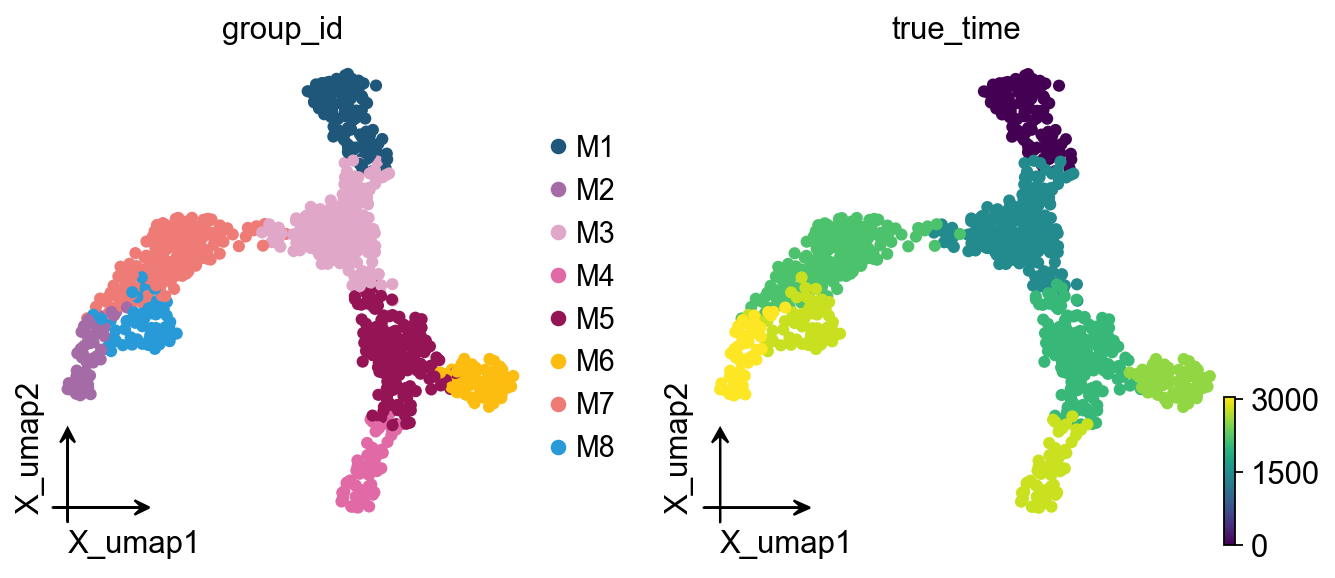

In [4]:
ov.pl.embedding(
    adata,
    basis="X_umap",
    color=["group_id", "true_time"],
    frameon="small",
    cmap="viridis",
)

In [5]:
# 官方标签存储在 adata.obs["group_id"] 中，true_time 可用于检查模拟轨迹方向。
adata.obs[["group_id", "true_time"]].head()

   group_id  true_time
C1       M3       1444
C2       M6       2548
C3       M5       2048
C4       M7       2182
C5       M7       2182

## 构建并运行模型

In [6]:
ncomps = 30
knn = 15
random_seed = 4
root = "M1"
memory = 0
use_rep = "X_pca"
clusters = "group_id"
basis = "X_umap"

stavia = ov.single.StaVIA(
    adata,
    use_rep=use_rep,
    n_comps=ncomps,
    basis=basis,
    cluster_key=clusters,
    spatial_key=None,  # 空间 AnnData 可设置为 "spatial"
    time_key=None,
    sample_key=None,
    key_added="stavia",
    root=root,
    knn=knn,
    random_seed=random_seed,
    memory=memory,
    dataset="group",
    num_threads=1,
    n_iter_leiden=5,
    small_pop=5,
    num_mcmc_simulations=200,
    edgepruning_clustering_resolution=0.15,
    cluster_graph_pruning=0.15,
    resolution_parameter=1.5,
)

stavia.fit()
v0 = stavia.model
stavia_embedding = np.asarray(adata.obsm[stavia.basis])[:, [0, 1]]


2026-05-23 03:39:01.652216	Running VIA over input data of 1000 (samples) x 30 (features)
2026-05-23 03:39:01.652307	Knngraph has 15 neighbors
2026-05-23 03:39:01.817576	Finished global pruning of 15-knn graph used for clustering at level of 0.15. Kept 47.3 % of edges. 
2026-05-23 03:39:01.819446	Number of connected components used for clustergraph  is 1
2026-05-23 03:39:01.828128	Commencing community detection


2026-05-23 03:39:01.864501	Finished community detection. Found 34 clusters.
2026-05-23 03:39:01.864955	Merging 20 very small clusters (<5)
2026-05-23 03:39:01.865372	Finished detecting communities. Found 14 communities
2026-05-23 03:39:01.865417	Making cluster graph. Global cluster graph pruning level: 0.15
2026-05-23 03:39:01.866390	Graph has 1 connected components before pruning
2026-05-23 03:39:01.866850	Graph has 4 connected components after pruning
2026-05-23 03:39:01.867481	Graph has 1 connected components after reconnecting
2026-05-23 03:39:01.867609	0.0% links trimmed from local pruning relative to start
2026-05-23 03:39:01.867617	31.6% links trimmed from global pruning relative to start
initial links 38 and final_links_n 38
2026-05-23 03:39:01.868576	component number 0 out of  [0]
2026-05-23 03:39:01.873345	group root method
2026-05-23 03:39:01.873369	for component 0, the root is M1 and ri M1
cluster 0 has majority M7
cluster 1 has majority M3
cluster 2 has majority M5
cluster

2026-05-23 03:39:05.490090	Ended all multiprocesses, will retrieve and reshape
2026-05-23 03:39:05.503269	start computing walks with rw2 method


  0%|          | 0/1300 [00:00<?, ?it/s]

memory for rw2 hittings times  2. Using rw2 based pt
2026-05-23 03:39:08.569181	Identifying terminal clusters corresponding to unique lineages...
2026-05-23 03:39:08.569197	Closeness:[4, 5, 6, 7, 9, 11, 13]
2026-05-23 03:39:08.569204	Betweenness:[3, 5, 6, 7, 8, 9, 11, 13]
2026-05-23 03:39:08.569209	Out Degree:[0, 3, 5, 6, 7, 8, 11, 13]
2026-05-23 03:39:08.569316	Terminal clusters corresponding to unique lineages in this component are [5, 7, 8, 9, 11, 13] 
Via 1.0 lineage prob


...

2026-05-23 03:39:30.904490	From root 6,  the Terminal state 11 is reached 13 times.
terminal state 11 has probability [0.909 0.255 0.    0.255 0.909 0.    0.255 0.    0.    0.326 0.    1.
 0.455 0.326]


2026-05-23 03:39:35.372384	From root 6,  the Terminal state 13 is reached 20 times.
terminal state 13 has probability [0.87  0.2   0.    0.2   0.87  0.    0.2   0.    0.    0.952 0.    0.812
 0.426 1.   ]
2026-05-23 03:39:35.388116	There are (6) terminal clusters corresponding to unique lineages {5: 'M6', 7: 'M4', 8: 'M5', 9: 'M2', 11: 'M8', 13: 'M2'}
2026-05-23 03:39:35.388173	Begin projection of pseudotime and lineage likelihood
2026-05-23 03:39:35.476759	Cluster graph layout based on forward biasing
2026-05-23 03:39:35.477155	Starting make edgebundle viagraph...


2026-05-23 03:39:37.501377	Make via clustergraph edgebundle


2026-05-23 03:39:37.827101	Hammer dims: Nodes shape: (14, 2) Edges shape: (26, 3)
2026-05-23 03:39:37.827683	Graph has 1 connected components before pruning
2026-05-23 03:39:37.828214	Graph has 4 connected components after pruning
2026-05-23 03:39:37.828901	Graph has 1 connected components after reconnecting
2026-05-23 03:39:37.829053	11.5% links trimmed from local pruning relative to start
2026-05-23 03:39:37.829064	34.6% links trimmed from global pruning relative to start
initial links 26 and final_links_n 23
2026-05-23 03:39:37.829826	Start making edgebundle milestone with 150 milestones...This can be recomputed with make_edgebundle_milestone()
2026-05-23 03:39:37.829839	Start finding milestones


2026-05-23 03:39:38.037826	End milestones with 150
2026-05-23 03:39:38.038044	Will use via-pseudotime for edges, otherwise consider providing a list of numeric labels (single cell level) or via_object
2026-05-23 03:39:38.039042	Recompute weights
2026-05-23 03:39:38.045824	pruning milestone graph based on recomputed weights
2026-05-23 03:39:38.046225	Graph has 1 connected components before pruning
2026-05-23 03:39:38.046465	Graph has 1 connected components after pruning
2026-05-23 03:39:38.046510	Graph has 1 connected components after reconnecting
2026-05-23 03:39:38.047408	61.6% links trimmed from global pruning relative to start
2026-05-23 03:39:38.048132	regenerate igraph on pruned edges
2026-05-23 03:39:38.051882	Setting numeric label as single cell pseudotime for coloring edges
2026-05-23 03:39:38.056452	Making smooth edges
REMEMBER TO RE-INCLUDE the PLT.SHOW HERE - COMMENTING IT OUT FOR NOW
2026-05-23 03:39:38.208476	Time elapsed 36.5 seconds


## StaVIA 图结构和伪时间


tune edges False


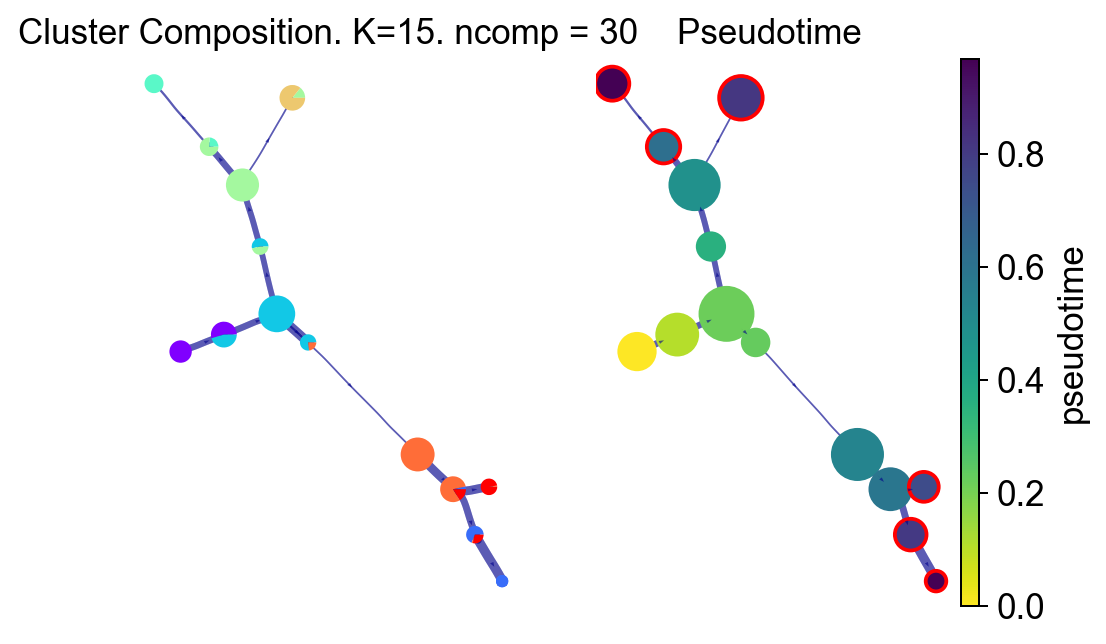

In [7]:
fig, ax, ax1 = VIA.core.plot_piechart_viagraph(
    via_object=v0,
    dpi=90,
    ax_text=False,
    show_legend=False,
)
fig.set_size_inches(6, 4)
plt.show()


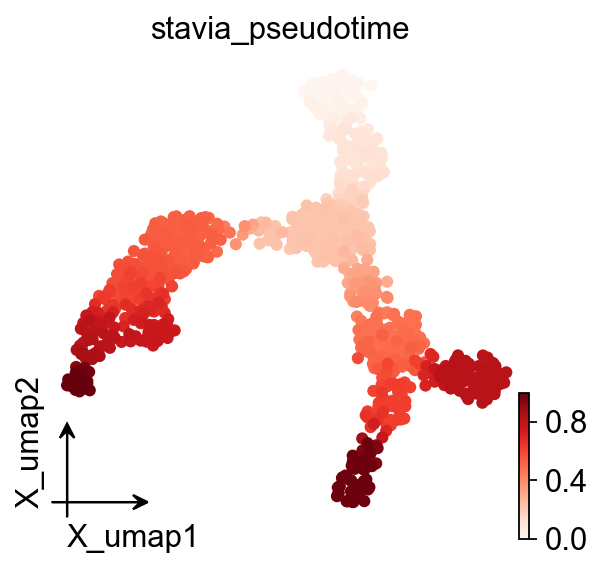

In [8]:
ov.pl.embedding(
    adata,
    basis=basis,
    color=[stavia.pseudotime_key],
    frameon="small",
    cmap="Reds",
)

## StaVIA 轨迹投影


  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--

 27% (3 of 11) |######                   | Elapsed Time: 0:00:00 ETA:   0:00:00

 54% (6 of 11) |#############            | Elapsed Time: 0:00:00 ETA:   0:00:00

 90% (10 of 11) |#####################   | Elapsed Time: 0:00:00 ETA:   0:00:00

100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00

...

 36% (4 of 11) |#########                | Elapsed Time: 0:00:00 ETA:   0:00:00

 72% (8 of 11) |##################       | Elapsed Time: 0:00:00 ETA:   0:00:00

 90% (10 of 11) |#####################   | Elapsed Time: 0:00:00 ETA:   0:00:00

100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00

2026-05-23 03:39:41.222177	Super cluster 5 is a super terminal with sub_terminal cluster 5
2026-05-23 03:39:41.223304	Super cluster 7 is a super terminal with sub_terminal cluster 7
2026-05-23 03:39:41.223314	Super cluster 8 is a super terminal with sub_terminal cluster 8
2026-05-23 03:39:41.223322	Super cluster 9 is a super terminal with sub_terminal cluster 9
2026-05-23 03:39:41.223333	Super cluster 11 is a super terminal with sub_terminal cluster 11
2026-05-23 03:39:41.223341	Super cluster 13 is a super terminal with sub_terminal cluster 13


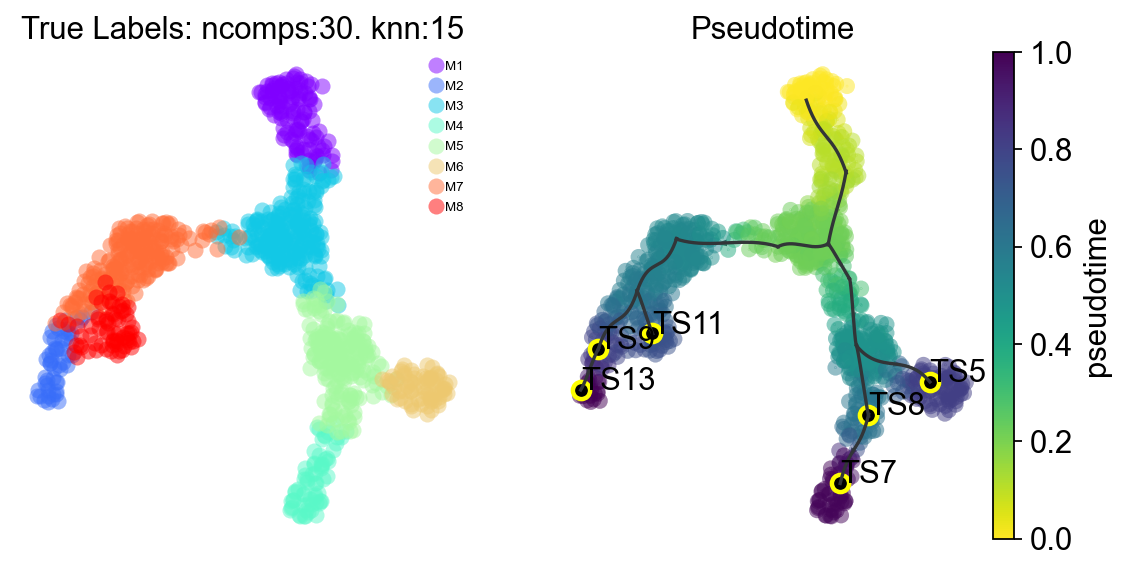

In [9]:
fig, ax, ax1 = VIA.core.plot_trajectory_curves(
    via_object=v0,
    embedding=stavia_embedding,
    dpi=80,
    draw_all_curves=False,
)
fig.set_size_inches(8, 4)
plt.show()


## StaVIA 谱系概率

参考 `t_via.ipynb` 中的 probabilistic pathways 小节，先展示所有终末谱系概率，再选择前两个终末谱系单独查看。

2026-05-23 03:39:41.470040	Marker_lineages: [5, 7, 8, 9, 11, 13]
2026-05-23 03:39:41.470606	The number of components in the original full graph is 1
2026-05-23 03:39:41.470641	For downstream visualization purposes we are also constructing a low knn-graph 


2026-05-23 03:39:41.723577	Check sc pb 0.9999999999999999 
f getting majority comp
2026-05-23 03:39:41.731211	Cluster path on clustergraph starting from Root Cluster 6 to Terminal Cluster 5: [6, 3, 1, 10, 2, 5]
2026-05-23 03:39:41.731224	Cluster path on clustergraph starting from Root Cluster 6 to Terminal Cluster 7: [6, 3, 1, 10, 2, 8, 7]
2026-05-23 03:39:41.731231	Cluster path on clustergraph starting from Root Cluster 6 to Terminal Cluster 8: [6, 3, 1, 10, 2, 8]
2026-05-23 03:39:41.731237	Cluster path on clustergraph starting from Root Cluster 6 to Terminal Cluster 9: [6, 3, 1, 12, 0, 4, 9]
2026-05-23 03:39:41.731242	Cluster path on clustergraph starting from Root Cluster 6 to Terminal Cluster 11: [6, 3, 1, 12, 0, 4, 11]
2026-05-23 03:39:41.731247	Cluster path on clustergraph starting from Root Cluster 6 to Terminal Cluster 13: [6, 3, 1, 12, 0, 4, 9, 13]
setting vmin to 0.0
2026-05-23 03:39:41.750468	Revised Cluster level path on sc-knnGraph from Root Cluster 6 to Terminal Cluster 5

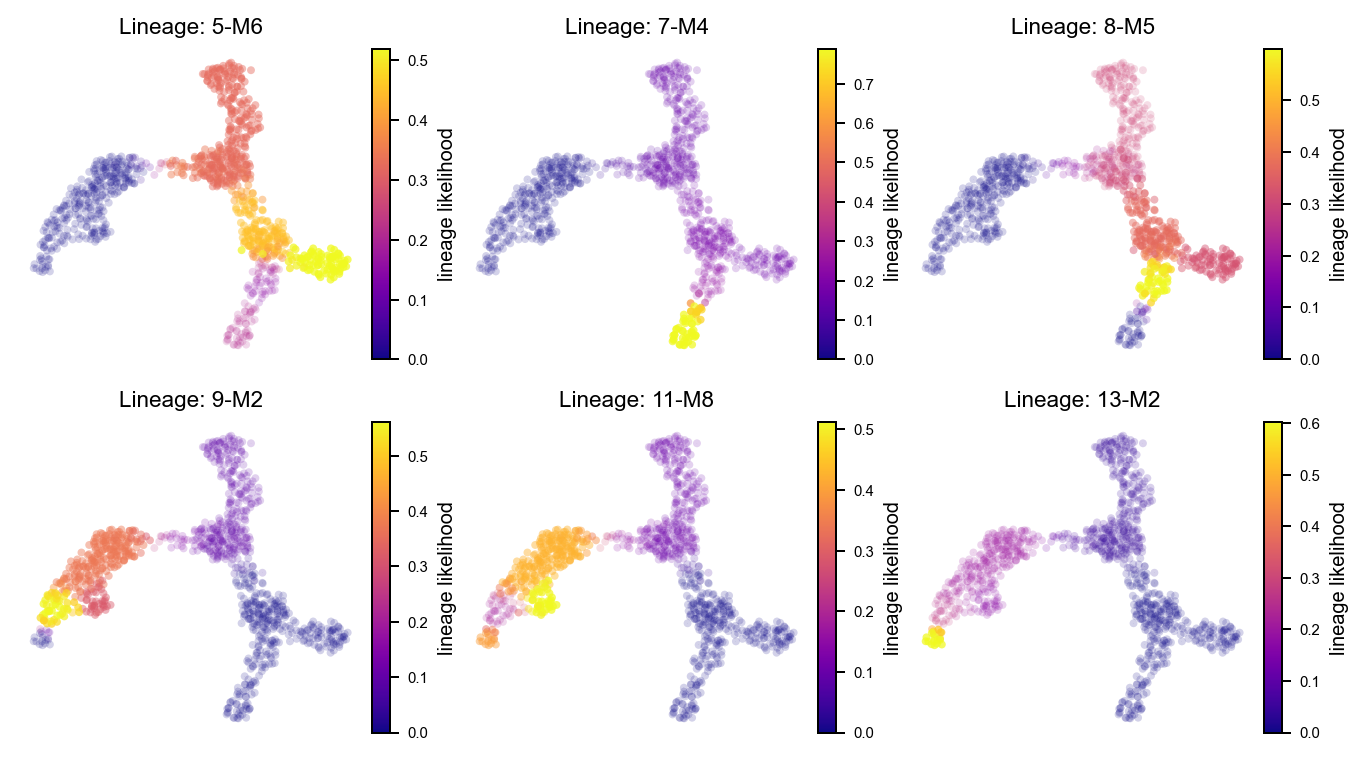

In [10]:
fig, axs = VIA.core.plot_sc_lineage_probability(
    via_object=v0,
    embedding=stavia_embedding,
    dpi=90,
)
fig.set_size_inches(9, 5)
plt.show()


2026-05-23 03:39:41.929891	Marker_lineages: [5, 7]
2026-05-23 03:39:41.930254	The number of components in the original full graph is 1
2026-05-23 03:39:41.930267	For downstream visualization purposes we are also constructing a low knn-graph 


2026-05-23 03:39:42.180566	Check sc pb 0.9999999999999999 
f getting majority comp
2026-05-23 03:39:42.188399	Cluster path on clustergraph starting from Root Cluster 6 to Terminal Cluster 5: [6, 3, 1, 10, 2, 5]
2026-05-23 03:39:42.188412	Cluster path on clustergraph starting from Root Cluster 6 to Terminal Cluster 7: [6, 3, 1, 10, 2, 8, 7]
setting vmin to 0.0
2026-05-23 03:39:42.199883	Revised Cluster level path on sc-knnGraph from Root Cluster 6 to Terminal Cluster 5 along path: [6, 6, 6, 3, 1, 10, 2, 5, 5, 5, 5]
setting vmin to 0.0
2026-05-23 03:39:42.206493	Revised Cluster level path on sc-knnGraph from Root Cluster 6 to Terminal Cluster 7 along path: [6, 6, 6, 3, 1, 10, 2, 8, 7, 7, 7, 7, 7]


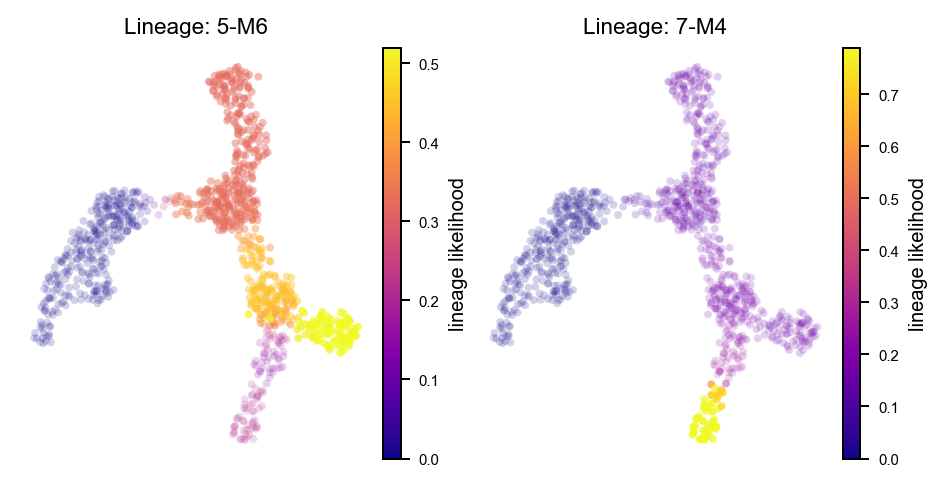

In [11]:
marker_lineages = list(v0.terminal_clusters)[:2]

fig, axs = VIA.core.plot_sc_lineage_probability(
    via_object=v0,
    embedding=stavia_embedding,
    marker_lineages=marker_lineages,
    dpi=90,
)
fig.set_size_inches(6, 3)
plt.show()


## StaVIA 谱系路径 atlas 图

location of 5 is at [0] and 0
setting vmin to 0.0


location of 7 is at [1] and 1
setting vmin to 0.0


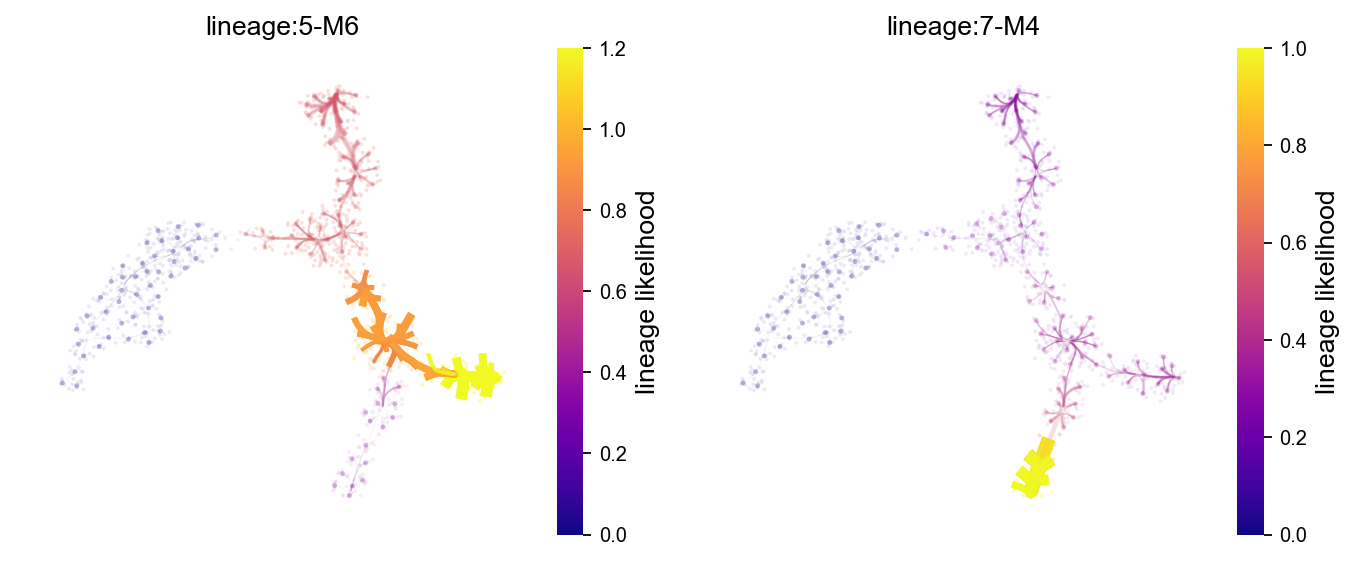

In [12]:
lineage_pathway = list(v0.terminal_clusters)[:2]

fig, axs = VIA.core.plot_atlas_view(
    via_object=v0,
    dpi=80,
    lineage_pathway=lineage_pathway,
    fontsize_title=12,
    fontsize_labels=12,
)
fig.set_size_inches(10, 4)
plt.show()

## StaVIA 流线图

参考 `t_via.ipynb` 中的 stream plot 示例，分别展示按注释着色的流线图和按伪时间着色的流线图。

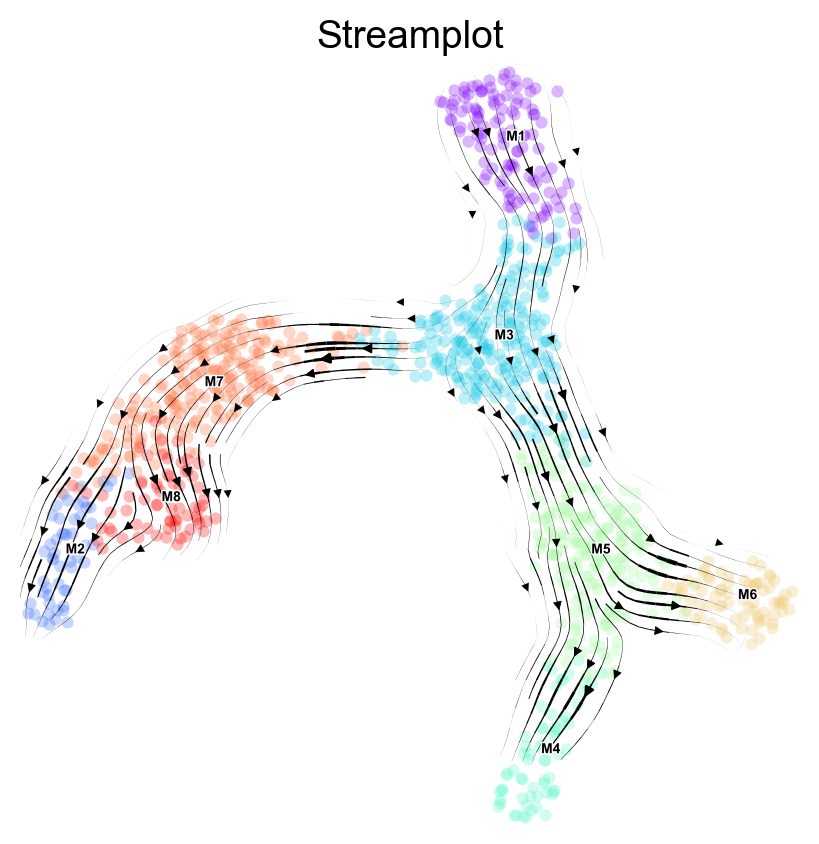

In [13]:
fig, ax = VIA.core.via_streamplot(
    via_object=v0,
    embedding=stavia_embedding,
    dpi=100,
    density_grid=1.0,
    density_stream=2.5,
    scatter_size=18,
    scatter_alpha=0.28,
    linewidth=0.8,
)
fig.set_size_inches(5, 5)
plt.show()


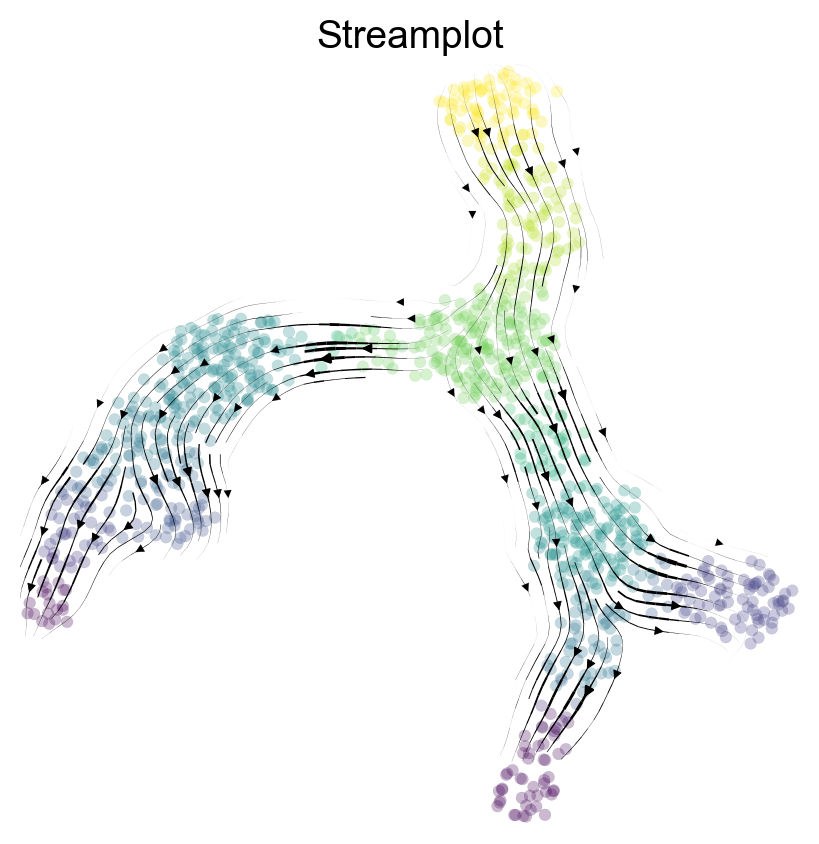

In [14]:
fig, ax = VIA.core.via_streamplot(
    via_object=v0,
    embedding=stavia_embedding,
    dpi=100,
    density_grid=1.0,
    density_stream=2.5,
    scatter_size=18,
    scatter_alpha=0.28,
    linewidth=0.8,
    color_scheme="time",
    min_mass=1,
    cutoff_perc=5,
    marker_edgewidth=0.1,
    smooth_transition=1,
    smooth_grid=0.5,
)
fig.set_size_inches(5, 5)
plt.show()


## 可视化基因/特征图

参考 `t_via.ipynb` 的 gene/feature graph 小节，先使用拟合后的 VIA 图对选定特征进行 MAGIC-like 平滑，再展示 cluster 水平的特征变化。

In [15]:
stavia_marker_genes = [
    gene
    for gene in ["G1", "G2", "G3", "G4", "G5", "G6"]
    if gene in adata.raw.var_names
]

df_gene = adata.raw[:, stavia_marker_genes].to_adata().to_df()
df_magic = v0.do_impute(
    df_gene,
    magic_steps=3,
    gene_list=stavia_marker_genes,
)

shape of transition matrix raised to power 3 (1000, 1000)


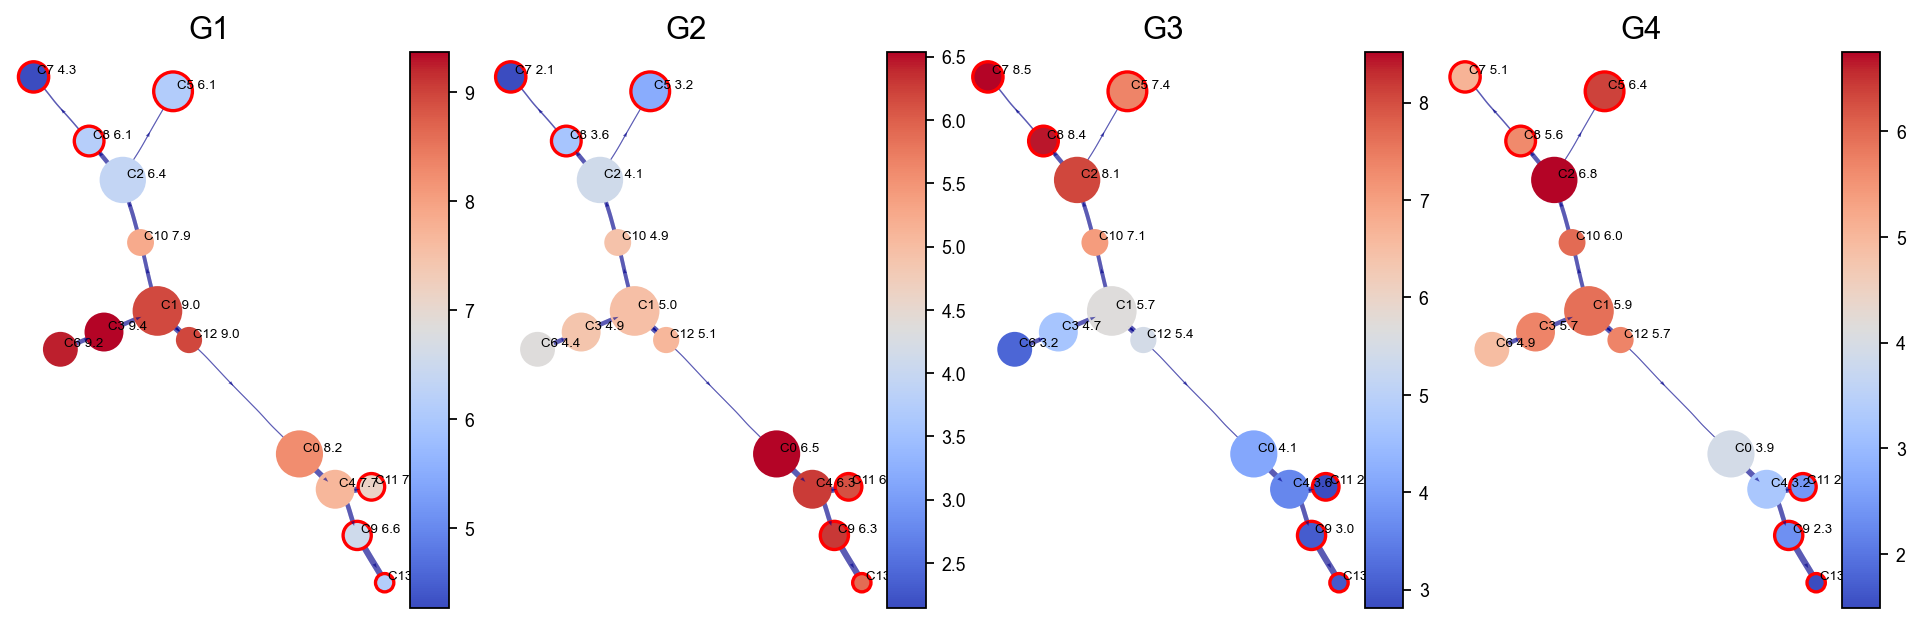

In [16]:
fig, axs = VIA.core.plot_viagraph(
    via_object=v0,
    type_data="gene",
    df_genes=df_magic.copy(),
    gene_list=stavia_marker_genes[:4],
    arrow_head=0.1,
)
fig.set_size_inches(12, 4)
plt.show()

## StaVIA 谱系基因动态

VIA 会沿检测到的终末谱系估计伪时间上的基因动态。下面先展示 VIA 原生趋势曲线和热图，再用 OmicVerse 的通用动态趋势/动态热图作为对照。

Area under curve G1 for branch M6 is 6.116569489951164
Area under curve G1 for branch M4 is 6.9543241010119115
Area under curve G1 for branch M5 is 5.789640204257873
Area under curve G1 for branch M2 is 7.1185843363452825
Area under curve G1 for branch M8 is 6.486565440364982
Area under curve G1 for branch M2 is 7.9849504853609545
Area under curve G2 for branch M6 is 3.5074403571393686
Area under curve G2 for branch M4 is 3.9264778447850732
Area under curve G2 for branch M5 is 3.3154362927101406
Area under curve G2 for branch M2 is 4.97171080515699
Area under curve G2 for branch M8 is 4.347326823695832
Area under curve G2 for branch M2 is 5.809097293813039
Area under curve G3 for branch M6 is 5.45345360594264
Area under curve G3 for branch M4 is 6.912371960844358
Area under curve G3 for branch M5 is 5.173672290912894
Area under curve G3 for branch M2 is 3.621194658116965
Area under curve G3 for branch M8 is 3.344708237098733
Area under curve G3 for branch M2 is 3.9799831968490804
Area 

Area under curve G6 for branch M2 is 5.475166349956863


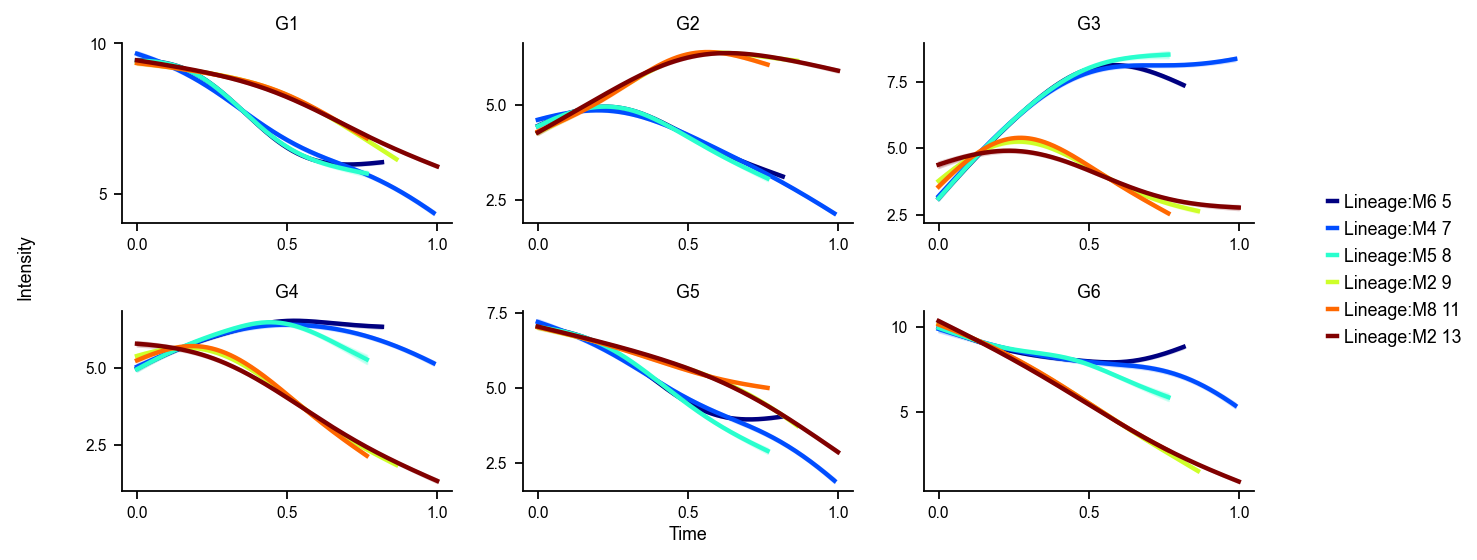

In [17]:
fig, axs = VIA.core.get_gene_expression(
    via_object=v0,
    gene_exp=df_magic[stavia_marker_genes],
    marker_genes=stavia_marker_genes,
    dpi=80,
    figsize=(10, 4),
    ncols=3,
    legend_loc="right",
)
plt.show()

branches [5, 7]


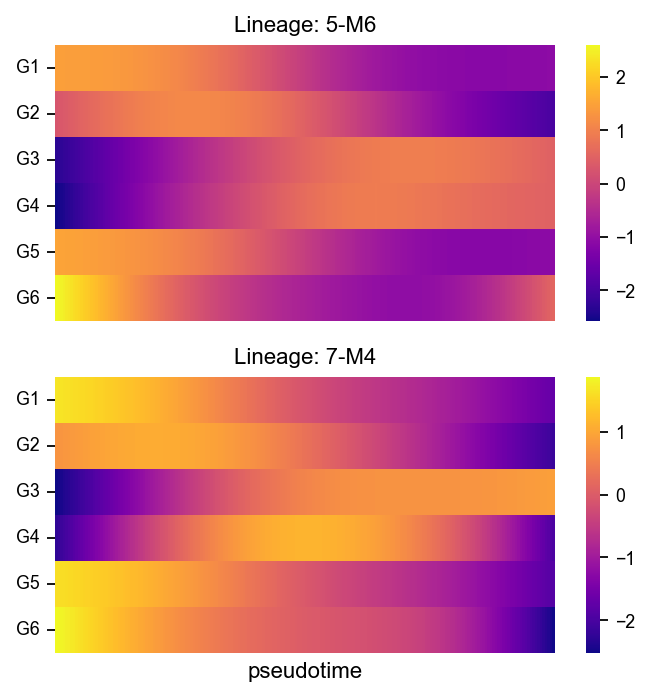

In [18]:
marker_lineages = list(v0.terminal_clusters)[:2]

fig, axs = VIA.core.plot_gene_trend_heatmaps(
    via_object=v0,
    df_gene_exp=df_magic[stavia_marker_genes],
    cmap="plasma",
    marker_lineages=marker_lineages,
)
fig.set_size_inches(5, max(3, 2.5 * len(marker_lineages)))
plt.show()